In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [3]:
# Loading and Preprocessing the Dataset

# if have not downloaded dataset uncomment and use this
# (train_images, train_labels), (test_images, test_labels) = cifar10.load_data()
# train_images, test_images = train_images / 255.0, test_images / 255.0
# train_labels = to_categorical(train_labels, 10)
# test_labels = to_categorical(test_labels, 10)


import pickle
import numpy as np
import os

def load_cifar10_batch(file_path):
    with open(file_path, 'rb') as f:
        batch = pickle.load(f, encoding='bytes')
    data = batch[b'data']
    labels = batch[b'labels']
    # تبدیل از (N, 3072) به (N, 32, 32, 3)
    data = data.reshape(-1, 3, 32, 32).transpose(0, 2, 3, 1)
    return data, np.array(labels)

def load_cifar10(root='./data'):
    base_path = os.path.join(root, 'cifar-10-batches-py')
    
    train_images = []
    train_labels = []
    for i in range(1, 6):
        file_path = os.path.join(base_path, f'data_batch_{i}')
        data, labels = load_cifar10_batch(file_path)
        train_images.append(data)
        train_labels.append(labels)
    
    train_images = np.concatenate(train_images)
    train_labels = np.concatenate(train_labels)
    
    test_file = os.path.join(base_path, 'test_batch')
    test_images, test_labels = load_cifar10_batch(test_file)
    
    return (train_images, train_labels), (test_images, test_labels)

(train_images, train_labels), (test_images, test_labels) = load_cifar10(root='./data')

train_images, test_images = train_images / 255.0, test_images / 255.0
train_labels = to_categorical(train_labels, 10)
test_labels = to_categorical(test_labels, 10)

print("Train shape:", train_images.shape)   
print("Test shape:", test_images.shape)     

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


In [5]:
# Defining the CNN Model

model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])


In [6]:
# Compiling the Model

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [7]:
# Training the Model

history = model.fit(train_images, train_labels, epochs=10, batch_size=64, validation_data=(test_images, test_labels))

Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 29ms/step - accuracy: 0.4635 - loss: 1.5041 - val_accuracy: 0.5416 - val_loss: 1.2850
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.5812 - loss: 1.1974 - val_accuracy: 0.5795 - val_loss: 1.1984
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.6242 - loss: 1.0807 - val_accuracy: 0.5897 - val_loss: 1.1863
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 26ms/step - accuracy: 0.6544 - loss: 0.9928 - val_accuracy: 0.6216 - val_loss: 1.1031
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 20s 25ms/step - accuracy: 0.6792 - loss: 0.9231 - val_accuracy: 0.6302 - val_loss: 1.0586
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - accuracy: 0.6983 - loss: 0.8638 - val_accuracy: 0.6441 - val_loss: 1.0349
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 18s 22ms/step - accuracy: 0.7212 - loss: 0.8099 - val_accuracy: 0.6423 - val_loss: 1.0350
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.7348 - loss: 0.7625 - 

In [8]:
# Evaluating the Model

test_loss, test_acc = model.evaluate(test_images, test_labels)
print(f"Test accuracy: {test_acc * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6477 - loss: 1.0674
Test accuracy: 64.77%


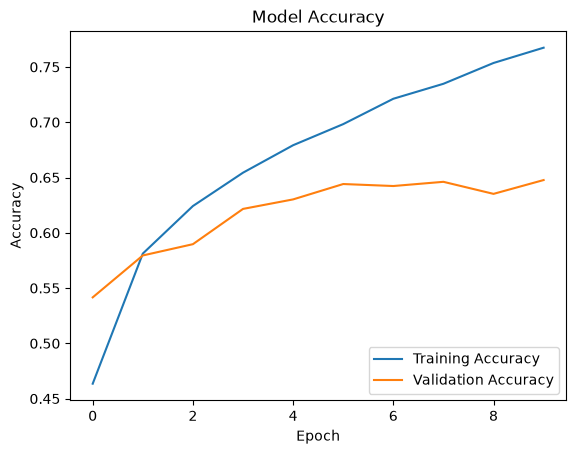

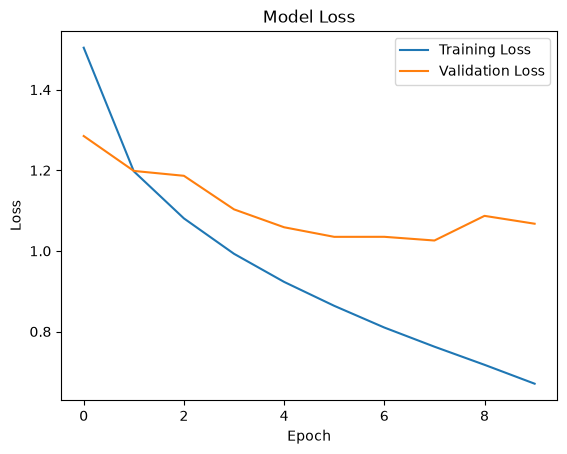

In [9]:
# Plotting Training History

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.show()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.show()